In [1]:
import config_annex_plot as annex_config
from fluxy.io import read_config_files
import os
import matplotlib.pyplot as plt

from fluxy.io import read_config_files, read_model_output, read_flux_total_fgases
from fluxy.operators.select import slice_flux
from fluxy.config import set_model_colors, set_model_labels
from fluxy.plots.flux_timeseries import plot_country_flux

region, output_path, inventory_years = "UK", "flkdjsbhlsbn/jblnbkefbln/", 2024


--- PLOTTING COUNTRY FLUXES FOR CH4/N2O ---


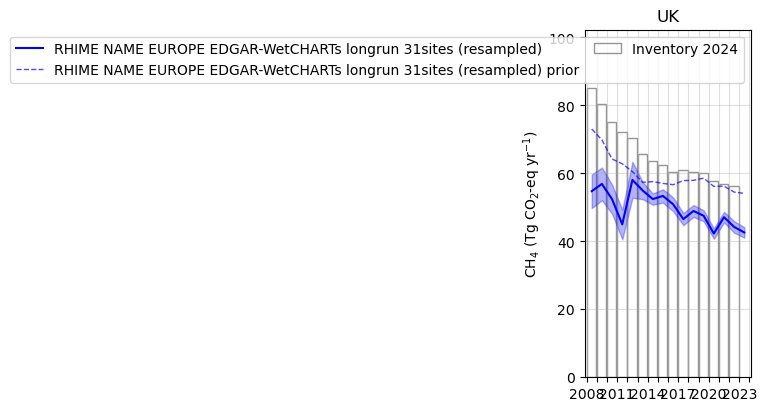

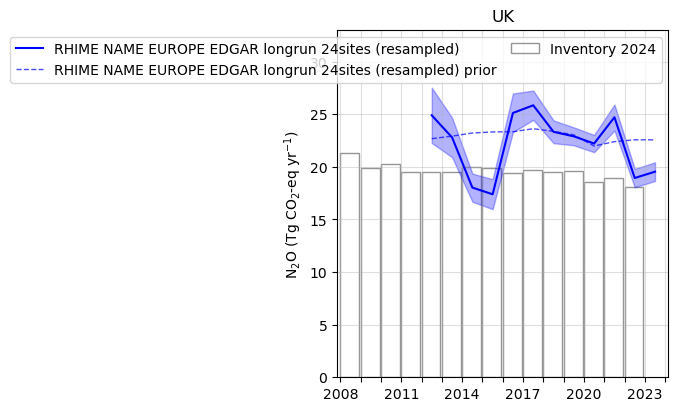

In [2]:
### Settings for country fluxes
models_country_fluxes = [
    # "RHIME_longrun",
    # "InTEM",
    # "ELRIS",
    "RHIME",
]  # NOTE: only options are basic model names w/ and w/o longrun
scale_co2eq = True
plot_inventory = True
fix_y_axes = False
add_prior = True
add_prior_unc = False
set_global_leg = False
country_codes_as_titles = None
# plot_separate = [True,False,False,False] # NOTE: easy fix while there are no Rhime results for N2O
# plot_combined = [False,True,True,True]
plot_resample_and_original = False
period_override = None
annex_mode = True

### Settings for spatial maps
models_spatial_maps = [#"InTEM", "ELRIS", 
                       "RHIME"]
plot_area = region
plot_site_locations = True
plot_point_markers = annex_config.point_markers[region]
convert_flux_units = True
set_fluxlim = "auto"
plot_inversion_grid_flux = True

### Initialization
config_data = read_config_files()    
annual_res_list = list()

### CH4 and N2O
print("\n--- PLOTTING COUNTRY FLUXES FOR CH4/N2O ---")
for species in annex_config.monthly_species:

    plot_separate = [True]#, False, False, False]
    plot_combined = [False]#, True, True, True]

    # Long time window
    start_date = "2008-01-01"
    end_date = "2024-01-01"

    ds_all_flux = {}
    ds_all_flux_scaled = {}
    models_std = []

    ### Read and scale fluxes
    for m, model in enumerate(models_country_fluxes):

        model_read = f"{model.split('_')[0]}_{config_data['models_info']['standard_run']['default'][species]}"
        print("WARNING : each team should check that the right files are used. Still to be checked by RHIME, ELRIS, InTEM.")
        if "longrun" in model:
            model_read = f"{model_read}_longrun"
        models_std.append(model_read)

    ds_all_flux = read_model_output(annex_config.data_dir,"flux",species,models_std,config_data,period="monthly")
    ds_all_flux_scaled = slice_flux(ds_all_flux,config_data,start_date,end_date,species=species,country_flux_units_print="Tg CO2-eq yr-1")
    

    ### Define plotting colors
    model_colors = set_model_colors(models_std)
    model_labels = set_model_labels(models_std,config_data,True)

    # Annual averages
    resample = "year"
    resample_uncert_correlation = False  # recalculates uncertainties assuming no correlation

    # 1.1) Plot annual country fluxes from 2008 to 2023 from intem_longrun and combined from 3 std_run
    fig, res = plot_country_flux(ds_all_flux_scaled,
                    species,
                    region,
                    config_data,
                    model_colors,
                    model_labels,
                    start_date,
                    end_date,
                    annex_mode,
                    plot_inventory,
                    inventory_years,
                    annex_config.data_dir,
                    fix_y_axes,
                    add_prior,
                    add_prior_unc,
                    set_global_leg,
                    country_codes_as_titles=country_codes_as_titles,
                    plot_separate=plot_separate,
                    plot_combined=plot_combined,
                    resample=resample,
                    resample_uncert_correlation=resample_uncert_correlation,
                    plot_resample_and_original=plot_resample_and_original,
                    rolling_mean=False,
                    return_res=True)

    plot_name = f"{species}_country_flux_annual_longrun_{region}.png"
    # full_path = os.path.join(output_path, plot_name)
    # fig.savefig(full_path, bbox_inches="tight", pad_inches=0.2, dpi=300)
    plt.show()

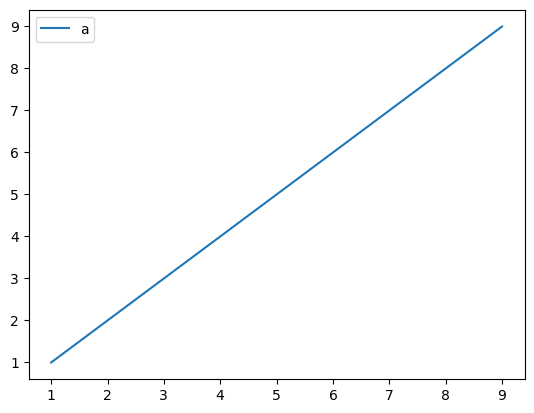

In [3]:
import matplotlib.pyplot as plt
import numpy as np

fig,ax = plt.subplots(1,1)
ax.plot(np.arange(1,10),np.arange(1,10),label="a")
leg = ax.legend(ncol=1, borderpad=0.4, columnspacing=1.0)

In [4]:
import matplotlib as mpl
print(mpl.__version__)

3.6.0


In [5]:
print(plt.__version__)

AttributeError: module 'matplotlib.pyplot' has no attribute '__version__'

In [7]:
annex_config.point_markers['UK']

['london', 'edinburgh', 'cardiff', 'belfast']